In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
df = pd.read_csv("train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [65]:
testdata = pd.read_csv("test.csv")

In [43]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [44]:
# Correlation of ALL columns with SalePrice
correlation = df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

correlation.head(15)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [45]:
sel_feature = [
    'OverallQual',
    'GrLivArea',
    'GarageCars',
    'TotalBsmtSF',
    'FullBath',
    'YearBuilt',
    'YearRemodAdd',
    'SalePrice'
]

df = df[sel_feature]
df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,YearRemodAdd,SalePrice
0,7,1710,2,856,2,2003,2003,208500
1,6,1262,2,1262,2,1976,1976,181500
2,7,1786,2,920,2,2001,2002,223500
3,7,1717,3,756,1,1915,1970,140000
4,8,2198,3,1145,2,2000,2000,250000


In [46]:
# Handling Missing Valuse

df.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
YearBuilt,0
YearRemodAdd,0
SalePrice,0


/tmp/ipykernel_2608/3955767779.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['SalePrice_log'] = np.log1p(df['SalePrice'])


Text(0.5, 0, 'Log Price')

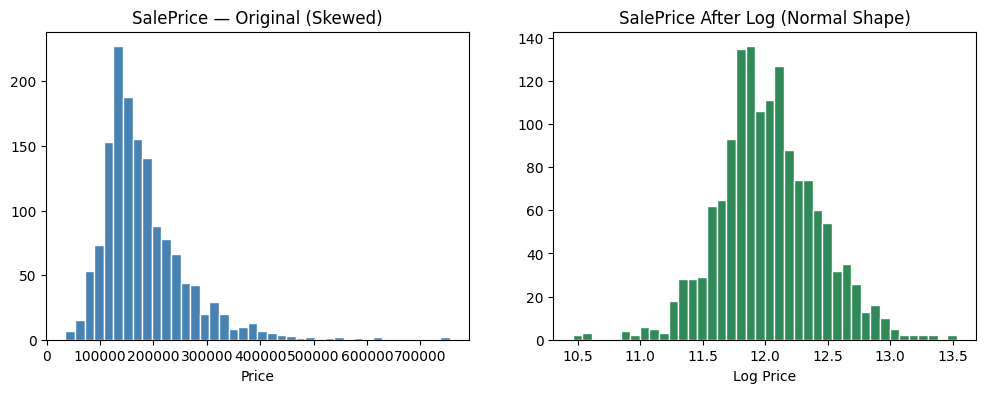

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df['SalePrice'], bins=40, color='steelblue', edgecolor='white')
plt.title('SalePrice — Original (Skewed)')
plt.xlabel('Price')


df['SalePrice_log'] = np.log1p(df['SalePrice'])

plt.subplot(1, 2, 2)
plt.hist(df['SalePrice_log'], bins=40, color='seagreen', edgecolor='white')
plt.title('SalePrice After Log (Normal Shape)')
plt.xlabel('Log Price')

In [81]:
print("\nOriginal SalePrice skewness:", round(df['SalePrice'].skew(), 2))
print("Log SalePrice skewness     :", round(df['SalePrice_log'].skew(), 2))


Original SalePrice skewness: 1.88
Log SalePrice skewness     : 0.12


## Correlation Heatmap

In [48]:
df.columns

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath',
       'YearBuilt', 'YearRemodAdd', 'SalePrice', 'SalePrice_log'],
      dtype='object')

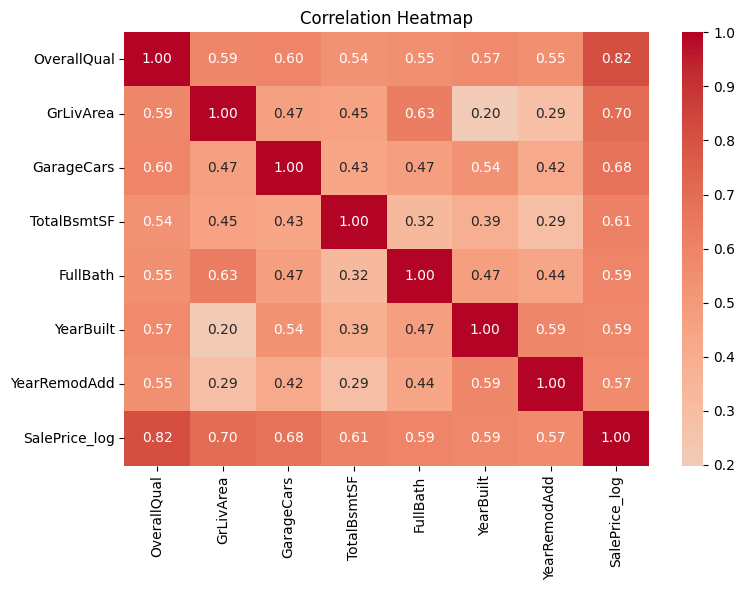

In [49]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['SalePrice']).corr(),
            annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()

## Overall Quality vs Sale Price

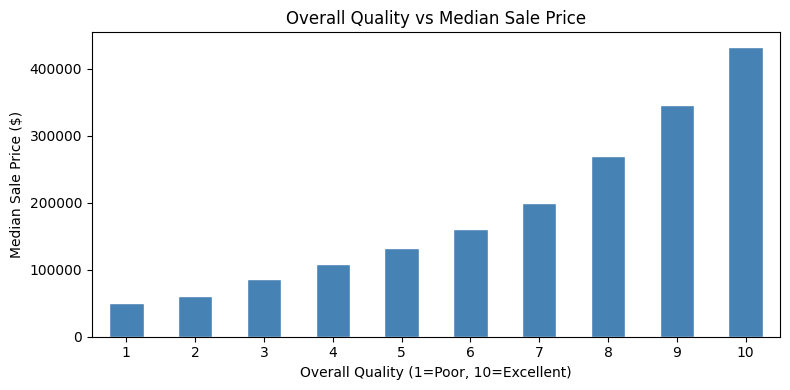

In [50]:
plt.figure(figsize=(8, 4))
df.groupby('OverallQual')['SalePrice'].median().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Overall Quality vs Median Sale Price')
plt.xlabel('Overall Quality (1=Poor, 10=Excellent)')
plt.ylabel('Median Sale Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()

## Living Area vs Sale Price

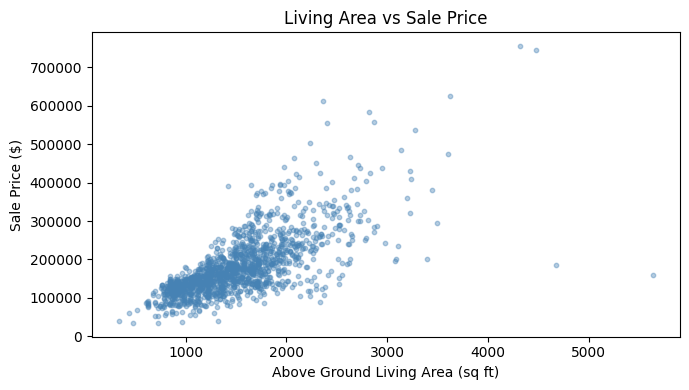

In [51]:
plt.figure(figsize=(7, 4))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, color='steelblue', s=10)
plt.title('Living Area vs Sale Price')
plt.xlabel('Above Ground Living Area (sq ft)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()


In [76]:
testdata.shape

(1459, 9)

In [52]:
# On Training data
df['HouseAge']   = 2010 - df['YearBuilt']
df['RemodelAge'] = 2010 - df['YearRemodAdd']

/tmp/ipykernel_2608/2857991899.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['HouseAge']   = 2010 - df['YearBuilt']
/tmp/ipykernel_2608/2857991899.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RemodelAge'] = 2010 - df['YearRemodAdd']


In [70]:
print(df[['YearBuilt', 'HouseAge', 'YearRemodAdd', 'RemodelAge']].head())

   YearBuilt  HouseAge  YearRemodAdd  RemodelAge
0       2003         7          2003           7
1       1976        34          1976          34
2       2001         9          2002           8
3       1915        95          1970          40
4       2000        10          2000          10


In [55]:
features = ['OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBsmtSF', 'FullBath', 'HouseAge', 'RemodelAge']
x = df[features]
y = df['SalePrice_log']

In [78]:
print(x.shape)
print(y.shape)

(1460, 7)
(1460,)


### Model Training and Evaluation

In [79]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing  samples:", len(X_test))


Training samples: 1168
Testing  samples: 292


In [118]:
X_test.shape

(292, 7)

# Scaling Features

In [80]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test   = scaler.transform(X_test)

In [100]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)


LinearRegression()

In [101]:
model_ridge = Ridge(alpha=10)
model_ridge.fit(X_train, y_train)
print("Ridge Regression trained!")

model_lasso = Lasso(alpha=0.001)
model_lasso.fit(X_train, y_train)
print("Lasso Regression trained!")

Ridge Regression trained!
Lasso Regression trained!


In [102]:
models = {
    'Linear Regression': model_lr,
    'Ridge (alpha=10)' : model_ridge,
    'Lasso (alpha=0.001)': model_lasso
}
results = []

In [127]:
for name, model in models.items():
    pred_log = model.predict(X_test)

    pred_actual = np.expm1(pred_log)
    actual = np.expm1(y_test)

    mae = mean_absolute_error(actual, pred_actual)
    r2  = r2_score(y_test, pred_log)

    results.append([name, mae, r2])

    print(f"\n{name}")
    print(f"  MAE = ${mae:,.0f}")
    print(f"  R²  = {r2:.4f}")

results_df = pd.DataFrame(results, columns=["Model", "MAE", "R2"])
print("\nFinal Comparison:")
print(results_df.sort_values(by="R2", ascending=False))



Linear Regression
  MAE = $20,611
  R²  = 0.8433

Ridge (alpha=10)
  MAE = $20,628
  R²  = 0.8431

Lasso (alpha=0.001)
  MAE = $20,615
  R²  = 0.8431

Final Comparison:
                 Model           MAE        R2
0    Linear Regression  20611.227959  0.843260
3    Linear Regression  20611.227959  0.843260
5  Lasso (alpha=0.001)  20615.180486  0.843143
2  Lasso (alpha=0.001)  20615.180486  0.843143
1     Ridge (alpha=10)  20627.925607  0.843093
4     Ridge (alpha=10)  20627.925607  0.843093


# **Testing on the TEST.csv data**

# Feature selection

In [75]:
# testdata = testdata[[
#     'OverallQual',
#     'GrLivArea',
#     'GarageCars',
#     'TotalBsmtSF',
#     'FullBath',
#     'YearBuilt',
#     'YearRemodAdd'
# ]]
testdata['HouseAge']   = 2010 - testdata['YearBuilt']
testdata['RemodelAge'] = 2010 - testdata['YearRemodAdd']


Index(['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath',
       'YearBuilt', 'YearRemodAdd', 'HouseAge', 'RemodelAge'],
      dtype='object')

In [130]:
testdata = testdata[['OverallQual', 'GrLivArea', 'GarageCars',
            'TotalBsmtSF', 'FullBath', 'HouseAge', 'RemodelAge']]

In [132]:
X_Final_test = testdata

In [133]:
X_Final_test.shape

(1459, 7)

In [134]:
X_Final_test.isnull().sum()

,0
OverallQual,0
GrLivArea,0
GarageCars,1
TotalBsmtSF,1
FullBath,0
HouseAge,0
RemodelAge,0


In [139]:
# handle missing value
X_Final_test = X_Final_test.fillna(X_Final_test.median())

In [141]:
X_Final_test_scaled = scaler.transform(X_Final_test)

In [143]:
predicted_log = model_lr.predict(X_Final_test_scaled)
predicted_prices = np.expm1(predicted_log)

In [144]:
print("\nFirst 10 predicted prices:")
for i, price in enumerate(predicted_prices[:10]):
    print(f"  House {i+1}: ${price:,.0f}")


First 10 predicted prices:
  House 1: $111,654
  House 2: $140,901
  House 3: $166,960
  House 4: $182,252
  House 5: $205,236
  House 6: $178,099
  House 7: $170,462
  House 8: $173,650
  House 9: $193,552
  House 10: $115,843


In [147]:
X_Final_test['Predicted_SalePrice'] = predicted_prices

X_Final_test.to_csv("final_predictions_full.csv", index=False)